In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# =============================================================
# 1. LOAD DATA
# =============================================================
data = pd.read_csv('/Users/muhammadzuamaalamin/Documents/percobaancvd/datasetfix/heart_disease_new_dataset1.csv')
print("Shape awal:", data.shape)

Shape awal: (438693, 304)


In [3]:
# =============================================================
# 2. HAPUS KOLOM MISSING VALUES >= 30%
# =============================================================
miss = data.isnull().mean() * 100
cols_to_drop_miss = miss[miss >= 15].index.tolist()

print(f"\nKolom dihapus karena missing >= 10% ({len(cols_to_drop_miss)}):")
print(cols_to_drop_miss)

data1 = data.drop(columns=cols_to_drop_miss)
print(f"\nShape setelah hapus missing: {data1.shape}")


Kolom dihapus karena missing >= 10% (165):
['CTELENM1', 'PVTRESD1', 'COLGHOUS', 'STATERE1', 'CELPHON1', 'LADULT1', 'COLGSEX', 'NUMADULT', 'LANDSEX', 'NUMMEN', 'NUMWOMEN', 'RESPSLCT', 'SAFETIME', 'CTELNUM1', 'CELLFON5', 'CADULT1', 'CELLSEX', 'PVTRESD3', 'CCLGHOUS', 'CSTATE1', 'LANDLINE', 'HHADULT', 'POORHLTH', 'BPMEDS', 'ASTHNOW', 'DIABAGE3', 'ARTHEXER', 'ARTHEDU', 'LMTJOIN3', 'ARTHDIS2', 'JOINPAI2', 'NUMHHOL3', 'NUMPHON3', 'PREGNANT', 'SMOKDAY2', 'AVEDRNK3', 'DRNK3GE5', 'MAXDRNKS', 'FLSHTMY3', 'IMFVPLA2', 'HIVTSTD3', 'PDIABTST', 'PREDIAB1', 'INSULIN1', 'BLDSUGAR', 'FEETCHK3', 'DOCTDIAB', 'CHKHEMO3', 'FEETCHK', 'EYEEXAM1', 'DIABEYE', 'DIABEDU', 'TOLDCFS', 'HAVECFS', 'WORKCFS', 'TOLDHEPC', 'TRETHEPC', 'PRIRHEPC', 'HAVEHEPC', 'HAVEHEPB', 'MEDSHEPB', 'HPVADVC4', 'HPVADSHT', 'TETANUS1', 'SHINGLE2', 'LCSFIRST', 'LCSLAST', 'LCSNUMCG', 'LCSCTSCN', 'HADMAM', 'HOWLONG', 'CERVSCRN', 'CRVCLCNC', 'CRVCLPAP', 'CRVCLHPV', 'HADHYST2', 'PSATEST1', 'PSATIME1', 'PCPSARS2', 'PCSTALK', 'HADSIGM4', 'COLNSI

In [4]:
# ============================================================
# DEFINISI FITUR (sudah deduplikasi)
# ============================================================
fitur_paper = [
    # --- Cardiovascular / Target ---
    'CVD_LABEL',    # Label/Target
    '_MICHD',       # Heart Problems (CHD/MI)
    'CVDSTRK3',     # Stroke
    'CVDCRHD4',     # Coronary Heart Disease
    'CVDINFR4',     # Heart Attack

    # --- Blood Pressure & Cholesterol ---
    '_RFHYPE6',     # High Blood Pressure (calculated)
    'BPHIGH6',      # Ever Told Blood Pressure High
    'TOLDHI3',      # High Cholesterol
    '_CHOLCH3',     # Cholesterol Check (calculated)
    'CHOLCHK3',     # Cholesterol Check (raw)

    # --- Metabolic & Chronic Conditions ---
    'DIABETE4',     # Diabetes
    'CHCKDNY2',     # Kidney Disease
    'CHCCOPD3',     # COPD
    'ASTHMA3',      # Asthma
    'ADDEPEV3',     # Depression
    '_DRDXAR3',     # Arthritis

    # --- BMI ---
    '_BMI5',        # BMI (continuous)
    '_BMI5CAT',     # BMI Category

    # --- Lifestyle ---
    'SMOKE100',     # Smoker
    '_TOTINDA',     # Physical Activity
    '_FRTLT1A',     # Fruits Consumption
    '_VEGLT1A',     # Veggies Consumption
    '_DRNKWK1',     # Alcohol Consumption

    # --- Health Status ---
    'GENHLTH',      # General Health
    'MENTHLTH',     # Mental Health
    'PHYSHLTH',     # Physical Health
    'DIFFWALK',     # Difficulty Walking
    'DECIDE',       # Difficulty Concentrating/Deciding

    # --- Healthcare Access ---
    '_HLTHPLN',     # Any Healthcare Coverage
    'MEDCOST1',     # No Doc because Cost
    'PERSDOC3',     # Personal Doctor
    'CHECKUP1',     # Last Routine Checkup

    # --- Preventive Care ---
    'PNEUVAC4',     # Pneumonia Vaccine
    'FLUSHOT7',     # Flu Shot
    '_AIDTST4',     # HIV Test

    # --- Demographics ---
    '_SEX',         # Sex
    '_AGEG5YR',     # Age Group
    'EDUCA',        # Education
    'INCOME3',      # Income
    'EMPLOY1',      # Employment Status
    '_PRACE1',      # Race
]

# Hapus duplikat sambil pertahankan urutan
fitur_paper = list(dict.fromkeys(fitur_paper))

# ============================================================
# CEK KOLOM DIABETES
# ============================================================
diabetes_cols = [c for c in data1.columns if 'DIAB' in c.upper()]
print("Kolom diabetes yang tersedia:", diabetes_cols)

# ============================================================
# CEK KETERSEDIAAN FITUR
# ============================================================
fitur_exist   = [c for c in fitur_paper if c in data1.columns]
fitur_missing = [c for c in fitur_paper if c not in data1.columns]

print(f"\n{'='*45}")
print(f"  Total fitur didefinisikan : {len(fitur_paper)}")
print(f"  Fitur ditemukan           : {len(fitur_exist)}")
print(f"  Fitur tidak ditemukan     : {len(fitur_missing)}")
print(f"{'='*45}")

if fitur_missing:
    print("\n⚠️  Fitur yang TIDAK ADA di dataset:")
    for i, col in enumerate(fitur_missing, 1):
        print(f"   {i:2}. {col}")

# ============================================================
# BUAT DATASET FINAL
# ============================================================
data_final = data1[fitur_exist].copy()

print(f"\n✅ Shape data final : {data_final.shape}")
print(f"\nFitur yang dipakai ({len(fitur_exist)} fitur):")
for i, col in enumerate(fitur_exist, 1):
    print(f"  {i:2}. {col}")

Kolom diabetes yang tersedia: ['DIABETE4']

  Total fitur didefinisikan : 41
  Fitur ditemukan           : 41
  Fitur tidak ditemukan     : 0

✅ Shape data final : (438693, 41)

Fitur yang dipakai (41 fitur):
   1. CVD_LABEL
   2. _MICHD
   3. CVDSTRK3
   4. CVDCRHD4
   5. CVDINFR4
   6. _RFHYPE6
   7. BPHIGH6
   8. TOLDHI3
   9. _CHOLCH3
  10. CHOLCHK3
  11. DIABETE4
  12. CHCKDNY2
  13. CHCCOPD3
  14. ASTHMA3
  15. ADDEPEV3
  16. _DRDXAR3
  17. _BMI5
  18. _BMI5CAT
  19. SMOKE100
  20. _TOTINDA
  21. _FRTLT1A
  22. _VEGLT1A
  23. _DRNKWK1
  24. GENHLTH
  25. MENTHLTH
  26. PHYSHLTH
  27. DIFFWALK
  28. DECIDE
  29. _HLTHPLN
  30. MEDCOST1
  31. PERSDOC3
  32. CHECKUP1
  33. PNEUVAC4
  34. FLUSHOT7
  35. _AIDTST4
  36. _SEX
  37. _AGEG5YR
  38. EDUCA
  39. INCOME3
  40. EMPLOY1
  41. _PRACE1


## Preprocessing 1

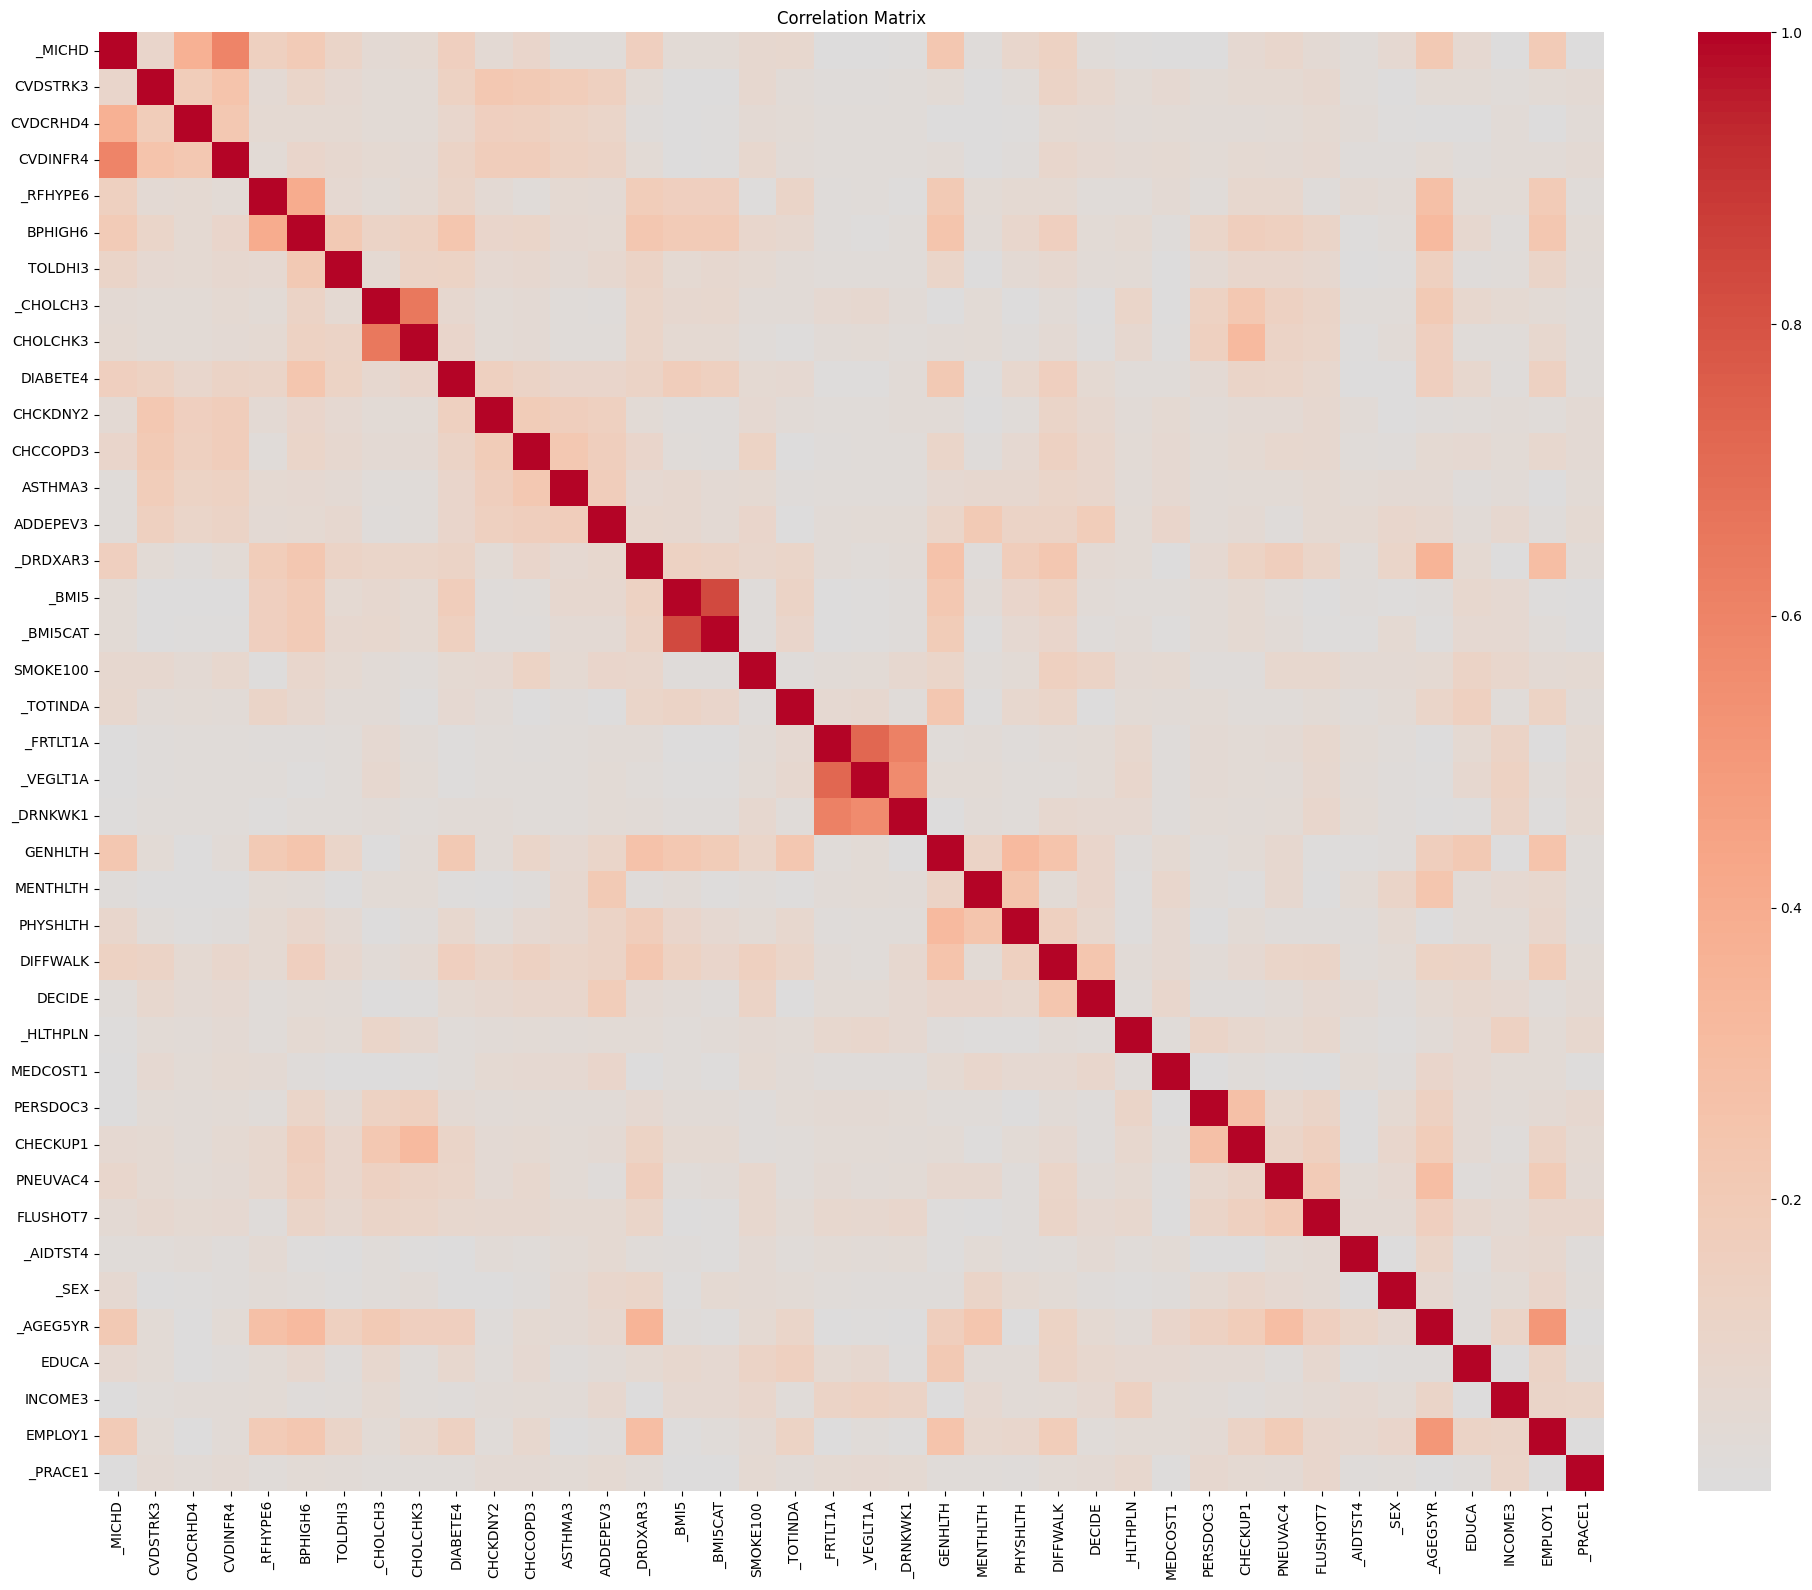

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Hitung korelasi
corr_matrix = data_final.select_dtypes(include='float64').corr().abs()

# Visualisasi heatmap
plt.figure(figsize=(20, 16))
sns.heatmap(corr_matrix, 
            cmap='coolwarm',
            center=0,
            annot=False,  # ganti True kalau mau lihat angkanya (lambat kalau banyak fitur)
            fmt='.2f')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

In [6]:
# Tampilkan pasangan fitur dengan korelasi > 0.85
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

high_corr = [(col, row, upper.loc[row, col]) 
             for col in upper.columns 
             for row in upper.index 
             if upper.loc[row, col] > 0.50]

high_corr_df = pd.DataFrame(high_corr, columns=['Fitur_1', 'Fitur_2', 'Korelasi'])
high_corr_df = high_corr_df.sort_values('Korelasi', ascending=False)

print(f"Pasangan fitur dengan korelasi > 0.85: {len(high_corr_df)}")
print(high_corr_df.to_string(index=False))

Pasangan fitur dengan korelasi > 0.85: 7
 Fitur_1  Fitur_2  Korelasi
_BMI5CAT    _BMI5  0.830420
_VEGLT1A _FRTLT1A  0.721476
CHOLCHK3 _CHOLCH3  0.648654
_DRNKWK1 _FRTLT1A  0.609881
CVDINFR4   _MICHD  0.600431
_DRNKWK1 _VEGLT1A  0.569375
 EMPLOY1 _AGEG5YR  0.511347


In [7]:
import pandas as pd
import numpy as np

# Nilai yang perlu diganti NaN per variabel
nan_map = {
    'CVDSTRK3':  [7.0, 9.0],
    'CVDCRHD4':  [7.0, 9.0],
    'CVDINFR4':  [7.0, 9.0],
    'BPHIGH6':   [7.0, 9.0],
    'TOLDHI3':   [7.0, 9.0],
    '_CHOLCH3':  [9.0],
    'CHOLCHK3':  [7.0, 9.0],
    'DIABETE4':  [7.0, 9.0],
    'CHCKDNY2':  [7.0, 9.0],
    'CHCCOPD3':  [7.0, 9.0],
    'ASTHMA3':   [7.0, 9.0],
    'ADDEPEV3':  [7.0, 9.0],
    '_DRDXAR3':  [],           # sudah NaN semua
    'SMOKE100':  [7.0, 9.0],
    '_TOTINDA':  [9.0],
    '_FRTLT1A':  [9.0],
    '_VEGLT1A':  [9.0],
    'GENHLTH':   [7.0, 9.0],
    'MENTHLTH':  [77.0, 99.0],
    'PHYSHLTH':  [77.0, 99.0],
    'DIFFWALK':  [7.0, 9.0],
    'DECIDE':    [7.0, 9.0],
    '_HLTHPLN':  [9.0],
    'MEDCOST1':  [7.0, 9.0],
    'PERSDOC3':  [7.0, 9.0],
    'CHECKUP1':  [7.0, 8.0, 9.0],
    'PNEUVAC4':  [7.0, 9.0],
    'FLUSHOT7':  [7.0, 9.0],
    '_AIDTST4':  [9.0],
    'EDUCA':     [9.0],
    'INCOME3':   [77.0, 99.0],
    'EMPLOY1':   [9.0],
    '_PRACE1':   [77.0, 99.0],
}

for col, invalid_vals in nan_map.items():
    if col in data_final.columns and invalid_vals:
        data_final[col] = data_final[col].replace(invalid_vals, np.nan)

print("Selesai! Cek missing values:")
print(data_final[nan_map.keys()].isna().sum())

Selesai! Cek missing values:
CVDSTRK3     1429
CVDCRHD4     4275
CVDINFR4     2655
BPHIGH6      1912
TOLDHI3     63980
_CHOLCH3    29782
CHOLCHK3    29782
DIABETE4      985
CHCKDNY2     1813
CHCCOPD3     2107
ASTHMA3      1746
ADDEPEV3     2517
_DRDXAR3     2896
SMOKE100    24461
_TOTINDA      928
_FRTLT1A    51087
_VEGLT1A    60127
GENHLTH      1161
MENTHLTH     7917
PHYSHLTH     9494
DIFFWALK    19830
DECIDE      19980
_HLTHPLN    17397
MEDCOST1     1364
PERSDOC3     3705
CHECKUP1     8216
PNEUVAC4    62801
FLUSHOT7    31392
_AIDTST4    51856
EDUCA        2478
INCOME3     94413
EMPLOY1      8251
_PRACE1     13363
dtype: int64


In [8]:
# Cek null semua kolom
null_summary = pd.DataFrame({
    'null_count': data_final.isnull().sum(),
    'null_percent': (data_final.isnull().sum() / len(data1) * 100).round(2)
}).sort_values('null_percent', ascending=False)

print(null_summary[null_summary['null_count'] > 0])

          null_count  null_percent
INCOME3        94413         21.52
TOLDHI3        63980         14.58
PNEUVAC4       62801         14.32
_VEGLT1A       60127         13.71
_AIDTST4       51856         11.82
_FRTLT1A       51087         11.65
_BMI5          46852         10.68
_BMI5CAT       46852         10.68
FLUSHOT7       31392          7.16
_CHOLCH3       29782          6.79
CHOLCHK3       29782          6.79
SMOKE100       24461          5.58
DECIDE         19980          4.55
DIFFWALK       19830          4.52
_HLTHPLN       17397          3.97
_PRACE1        13363          3.05
PHYSHLTH        9494          2.16
EMPLOY1         8251          1.88
CHECKUP1        8216          1.87
MENTHLTH        7917          1.80
_MICHD          4635          1.06
CVDCRHD4        4275          0.97
PERSDOC3        3705          0.84
_DRDXAR3        2896          0.66
CVDINFR4        2655          0.61
ADDEPEV3        2517          0.57
EDUCA           2478          0.56
CHCCOPD3        2107

In [9]:
data_final = data_final.drop(columns=['_BMI5CAT','INCOME3'])

In [10]:
# Cara 1 - Value counts semua kolom sekaligus
for col in data_final.columns:
    print(f"\n{'='*50}")
    print(f"Kolom: {col}")
    print(data_final[col].value_counts(dropna=False))


Kolom: CVD_LABEL
CVD_LABEL
Healt                391852
Stroke Only           11518
CHD Only              11048
Heart Attack Only     10295
MI + CHD               8285
MI + Stroke            2137
All Three              2114
CHD + Stroke           1444
Name: count, dtype: int64

Kolom: _MICHD
_MICHD
2.0    398735
1.0     35323
NaN      4635
Name: count, dtype: int64

Kolom: CVDSTRK3
CVDSTRK3
2.0    420051
1.0     17213
NaN      1429
Name: count, dtype: int64

Kolom: CVDCRHD4
CVDCRHD4
2.0    411527
1.0     22891
NaN      4275
Name: count, dtype: int64

Kolom: CVDINFR4
CVDINFR4
2.0    413207
1.0     22831
NaN      2655
Name: count, dtype: int64

Kolom: _RFHYPE6
_RFHYPE6
1.0    264648
2.0    172133
9.0      1912
Name: count, dtype: int64

Kolom: BPHIGH6
BPHIGH6
3.0    256603
1.0    172133
4.0      4571
2.0      3474
NaN      1912
Name: count, dtype: int64

Kolom: TOLDHI3
TOLDHI3
2.0    224989
1.0    149724
NaN     63980
Name: count, dtype: int64

Kolom: _CHOLCH3
_CHOLCH3
1.0    364002
3.0 

In [11]:
data_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438693 entries, 0 to 438692
Data columns (total 39 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   CVD_LABEL  438693 non-null  object 
 1   _MICHD     434058 non-null  float64
 2   CVDSTRK3   437264 non-null  float64
 3   CVDCRHD4   434418 non-null  float64
 4   CVDINFR4   436038 non-null  float64
 5   _RFHYPE6   438693 non-null  float64
 6   BPHIGH6    436781 non-null  float64
 7   TOLDHI3    374713 non-null  float64
 8   _CHOLCH3   408911 non-null  float64
 9   CHOLCHK3   408911 non-null  float64
 10  DIABETE4   437708 non-null  float64
 11  CHCKDNY2   436880 non-null  float64
 12  CHCCOPD3   436586 non-null  float64
 13  ASTHMA3    436947 non-null  float64
 14  ADDEPEV3   436176 non-null  float64
 15  _DRDXAR3   435797 non-null  float64
 16  _BMI5      391841 non-null  float64
 17  SMOKE100   414232 non-null  float64
 18  _TOTINDA   437765 non-null  float64
 19  _FRTLT1A   387606 non-n

In [12]:
data_final.describe()

,_MICHD,CVDSTRK3,CVDCRHD4,CVDINFR4,_RFHYPE6,BPHIGH6,TOLDHI3,_CHOLCH3,CHOLCHK3,DIABETE4,...,PERSDOC3,CHECKUP1,PNEUVAC4,FLUSHOT7,_AIDTST4,_SEX,_AGEG5YR,EDUCA,EMPLOY1,_PRACE1
count,434058.000000,437264.000000,434418.000000,436038.000000,438693.000000,436781.000000,374713.000000,408911.000000,408911.000000,437708.000000,...,434988.000000,430477.000000,375892.000000,407301.000000,386837.000000,438693.000000,438693.000000,436215.000000,430442.000000,425330.000000
mean,1.918621,1.960635,1.947307,1.947640,1.427244,2.214323,1.600430,1.186539,2.405142,2.750752,...,1.528159,1.356802,1.596778,1.479098,1.666506,1.535529,7.726016,5.012790,3.747225,1.431935
std,0.273416,0.194463,0.223421,0.222752,0.699127,0.988691,0.489811,0.552422,1.300781,0.704141,...,0.701113,0.772044,0.490545,0.499564,0.471462,0.498737,3.645926,1.007272,2.837228,1.143380
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,2.000000,2.000000,2.000000,2.000000,1.000000,1.000000,1.000000,1.000000,2.000000,3.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,5.000000,4.000000,1.000000,1.000000
50%,2.000000,2.000000,2.000000,2.000000,1.000000,3.000000,2.000000,1.000000,2.000000,3.000000,...,1.000000,1.000000,2.000000,1.000000,2.000000,2.000000,8.000000,5.000000,2.000000,1.000000
75%,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,2.000000,1.000000,2.000000,3.000000,...,2.000000,1.000000,2.000000,2.000000,2.000000,2.000000,11.000000,6.000000,7.000000,1.000000
max,2.000000,2.000000,2.000000,2.000000,9.000000,4.000000,2.000000,3.000000,8.000000,4.000000,...,3.000000,4.000000,2.000000,2.000000,2.000000,2.000000,14.000000,6.000000,8.000000,8.000000


In [13]:
data_final = data_final.drop(columns=['CVD_LABEL','CVDINFR4','CVDCRHD4'])
data_final

,_MICHD,CVDSTRK3,_RFHYPE6,BPHIGH6,TOLDHI3,_CHOLCH3,CHOLCHK3,DIABETE4,CHCKDNY2,CHCCOPD3,...,PERSDOC3,CHECKUP1,PNEUVAC4,FLUSHOT7,_AIDTST4,_SEX,_AGEG5YR,EDUCA,EMPLOY1,_PRACE1
0,2.0,2.0,1.0,3.0,1.0,1.0,2.0,3.0,2.0,1.0,...,1.0,2.0,1.0,1.0,2.0,2.0,11.0,4.0,7.0,1.0
1,1.0,2.0,2.0,1.0,1.0,1.0,2.0,1.0,1.0,2.0,...,2.0,1.0,2.0,2.0,2.0,2.0,10.0,6.0,8.0,2.0
2,1.0,2.0,2.0,1.0,2.0,1.0,2.0,1.0,2.0,2.0,...,2.0,1.0,2.0,2.0,2.0,2.0,11.0,4.0,7.0,2.0
3,2.0,2.0,2.0,1.0,1.0,1.0,2.0,1.0,2.0,2.0,...,1.0,1.0,2.0,1.0,2.0,2.0,9.0,4.0,7.0,1.0
4,1.0,1.0,1.0,4.0,1.0,1.0,2.0,1.0,2.0,2.0,...,1.0,1.0,1.0,1.0,1.0,1.0,12.0,3.0,8.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
438688,2.0,2.0,2.0,1.0,2.0,1.0,6.0,2.0,2.0,1.0,...,3.0,4.0,1.0,2.0,1.0,2.0,3.0,4.0,1.0,NaN
438689,2.0,2.0,2.0,1.0,2.0,1.0,2.0,1.0,2.0,2.0,...,1.0,1.0,2.0,2.0,2.0,1.0,13.0,4.0,8.0,6.0
438690,2.0,2.0,1.0,3.0,1.0,1.0,2.0,3.0,2.0,2.0,...,1.0,1.0,2.0,2.0,1.0,1.0,7.0,6.0,7.0,2.0
438691,2.0,2.0,2.0,1.0,2.0,1.0,2.0,3.0,2.0,2.0,...,2.0,1.0,2.0,2.0,1.0,1.0,10.0,4.0,7.0,NaN


In [14]:
data_new = data_final.dropna()
print(f"Sebelum : {len(data1)} baris")
print(f"Sesudah : {len(data_new)} baris")
print(f"Terhapus: {len(data1) - len(data_new)} baris")

Sebelum : 438693 baris
Sesudah : 236369 baris
Terhapus: 202324 baris


In [15]:
data_new['_MICHD'].value_counts()

_MICHD
2.0    215367
1.0     21002
Name: count, dtype: int64

In [16]:
severity_map = {
    2.0       : 0,  # Sehat
    1.0       : 1,  # Level 1 → 1 kondisi
}
data_new['_MICHD'] = data_new['_MICHD'].map(severity_map)

# Verifikasi
print(data_new['_MICHD'].value_counts())
print(f"\nTotal : {len(data1):,}")

_MICHD
0    215367
1     21002
Name: count, dtype: int64

Total : 438,693


/var/folders/c1/0skxdwdx0zdcpl8hlxr2xcz40000gn/T/ipykernel_6209/2707975189.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_new['_MICHD'] = data_new['_MICHD'].map(severity_map)


In [17]:
data_new.info()

<class 'pandas.core.frame.DataFrame'>
Index: 236369 entries, 0 to 438692
Data columns (total 36 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   _MICHD    236369 non-null  int64  
 1   CVDSTRK3  236369 non-null  float64
 2   _RFHYPE6  236369 non-null  float64
 3   BPHIGH6   236369 non-null  float64
 4   TOLDHI3   236369 non-null  float64
 5   _CHOLCH3  236369 non-null  float64
 6   CHOLCHK3  236369 non-null  float64
 7   DIABETE4  236369 non-null  float64
 8   CHCKDNY2  236369 non-null  float64
 9   CHCCOPD3  236369 non-null  float64
 10  ASTHMA3   236369 non-null  float64
 11  ADDEPEV3  236369 non-null  float64
 12  _DRDXAR3  236369 non-null  float64
 13  _BMI5     236369 non-null  float64
 14  SMOKE100  236369 non-null  float64
 15  _TOTINDA  236369 non-null  float64
 16  _FRTLT1A  236369 non-null  float64
 17  _VEGLT1A  236369 non-null  float64
 18  _DRNKWK1  236369 non-null  float64
 19  GENHLTH   236369 non-null  float64
 20  MENTHLTH 

In [18]:
X = data_new.drop(columns=['_MICHD'])
y = data_new['_MICHD']

### Training Model

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [20]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 189095 entries, 35131 to 162987
Data columns (total 35 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   CVDSTRK3  189095 non-null  float64
 1   _RFHYPE6  189095 non-null  float64
 2   BPHIGH6   189095 non-null  float64
 3   TOLDHI3   189095 non-null  float64
 4   _CHOLCH3  189095 non-null  float64
 5   CHOLCHK3  189095 non-null  float64
 6   DIABETE4  189095 non-null  float64
 7   CHCKDNY2  189095 non-null  float64
 8   CHCCOPD3  189095 non-null  float64
 9   ASTHMA3   189095 non-null  float64
 10  ADDEPEV3  189095 non-null  float64
 11  _DRDXAR3  189095 non-null  float64
 12  _BMI5     189095 non-null  float64
 13  SMOKE100  189095 non-null  float64
 14  _TOTINDA  189095 non-null  float64
 15  _FRTLT1A  189095 non-null  float64
 16  _VEGLT1A  189095 non-null  float64
 17  _DRNKWK1  189095 non-null  float64
 18  GENHLTH   189095 non-null  float64
 19  MENTHLTH  189095 non-null  float64
 20  PHYSH

In [21]:
class_labels = list(y_train.unique())
class_labels

[0, 1]

In [22]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import time

# ── Helper ──────────────────────────────────────────────────────────────────
def print_metrics(name, y_true, y_pred, y_prob=None, training_time=None):
    print(f"\n{'='*50}")
    print(f"  {name} Results")
    print(f"{'='*50}")
    if training_time is not None:
        print(f"  Training Time : {training_time:.4f}s")
    print(f"  Accuracy  : {accuracy_score(y_true, y_pred):.4f}")
    print(f"  Precision : {precision_score(y_true, y_pred):.4f}")
    print(f"  Recall    : {recall_score(y_true, y_pred):.4f}")
    print(f"  F1-Score  : {f1_score(y_true, y_pred):.4f}")
    if y_prob is not None:
        print(f"  ROC-AUC   : {roc_auc_score(y_true, y_prob):.4f}")
    print(f"\n  Classification Report:\n")
    print(classification_report(y_true, y_pred, target_names=[str(x) for x in class_labels]))


# 1. Random Forest Classifier
print("\n--- Training Random Forest Classifier ---")
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=5,
    class_weight='balanced',
    random_state=42
)
start = time.time()
rf_model.fit(X_train, y_train)
rf_time = time.time() - start
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]   # probability for positive class
print_metrics("Random Forest", y_test, y_pred_rf, y_prob=y_prob_rf, training_time=rf_time)


# 2. XGBoost Classifier
print("\n--- Training XGBoost Classifier ---")
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=7,
    learning_rate=0.2,
    eval_metric='logloss',          # binary: logloss (bukan mlogloss)
    objective='binary:logistic',    # binary objective
    random_state=42
)
start = time.time()
xgb_model.fit(X_train, y_train)
xgb_time = time.time() - start
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]
print_metrics("XGBoost", y_test, y_pred_xgb, y_prob=y_prob_xgb, training_time=xgb_time)


# 3. LightGBM Classifier
print("\n--- Training LightGBM Classifier ---")
lgbm_model = LGBMClassifier(
    n_estimators=200,
    max_depth=-1,
    learning_rate=0.2,
    class_weight='balanced',
    objective='binary',             # binary objective
    metric='binary_logloss',        # binary metric
    random_state=42
)
start = time.time()
lgbm_model.fit(X_train, y_train)
lgbm_time = time.time() - start
y_pred_lgbm = lgbm_model.predict(X_test)
y_prob_lgbm = lgbm_model.predict_proba(X_test)[:, 1]
print_metrics("LightGBM", y_test, y_pred_lgbm, y_prob=y_prob_lgbm, training_time=lgbm_time)


--- Training Random Forest Classifier ---

  Random Forest Results
  Training Time : 26.5109s
  Accuracy  : 0.9101
  Precision : 0.4823
  Recall    : 0.1652
  F1-Score  : 0.2461
  ROC-AUC   : 0.8366

  Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.98      0.95     43074
           1       0.48      0.17      0.25      4200

    accuracy                           0.91     47274
   macro avg       0.70      0.57      0.60     47274
weighted avg       0.88      0.91      0.89     47274


--- Training XGBoost Classifier ---

  XGBoost Results
  Training Time : 1.0011s
  Accuracy  : 0.9118
  Precision : 0.5138
  Recall    : 0.1286
  F1-Score  : 0.2057
  ROC-AUC   : 0.8370

  Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.99      0.95     43074
           1       0.51      0.13      0.21      4200

    accuracy                           0.91     47274
   macro avg  

In [23]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score,recall_score

# Hitung scale_pos_weight untuk class imbalance
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# Training model
model = XGBClassifier(
    n_estimators     = 100,
    max_depth        = 6,
    learning_rate    = 0.1,
    scale_pos_weight = scale_pos_weight,
    eval_metric      = 'logloss',
    random_state     = 42
)

model.fit(X_train, y_train)

# %%
# Evaluasi
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=['Sehat', 'CVD']))
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

       Sehat       0.97      0.74      0.84     43074
         CVD       0.23      0.80      0.36      4200

    accuracy                           0.75     47274
   macro avg       0.60      0.77      0.60     47274
weighted avg       0.91      0.75      0.80     47274

AUC-ROC: 0.8455

Confusion Matrix:
[[31952 11122]
 [  857  3343]]


Top 20 Feature Importance:
     feature  importance
0   _RFHYPE6    0.438963
1    GENHLTH    0.076175
2    EMPLOY1    0.053867
3   _AGEG5YR    0.053616
4    TOLDHI3    0.043158
5       _SEX    0.032123
6   CHCCOPD3    0.029166
7   CVDSTRK3    0.029091
8   PNEUVAC4    0.022991
9   DIFFWALK    0.022701
10  DIABETE4    0.020155
11  SMOKE100    0.020056
12   BPHIGH6    0.019618
13  PERSDOC3    0.016101
14  _DRDXAR3    0.015303
15  CHOLCHK3    0.013047
16  CHCKDNY2    0.010229
17  MEDCOST1    0.006880
18   ASTHMA3    0.006150
19     EDUCA    0.005880
20    DECIDE    0.005835
21  _DRNKWK1    0.005638
22   _PRACE1    0.005480
23  FLUSHOT7    0.004663
24  ADDEPEV3    0.004642
25  _HLTHPLN    0.004530
26  _AIDTST4    0.004189
27  MENTHLTH    0.004150
28  _TOTINDA    0.004101
29     _BMI5    0.003994
30  PHYSHLTH    0.003931
31  _CHOLCH3    0.003600
32  CHECKUP1    0.003547
33  _VEGLT1A    0.003518
34  _FRTLT1A    0.002910


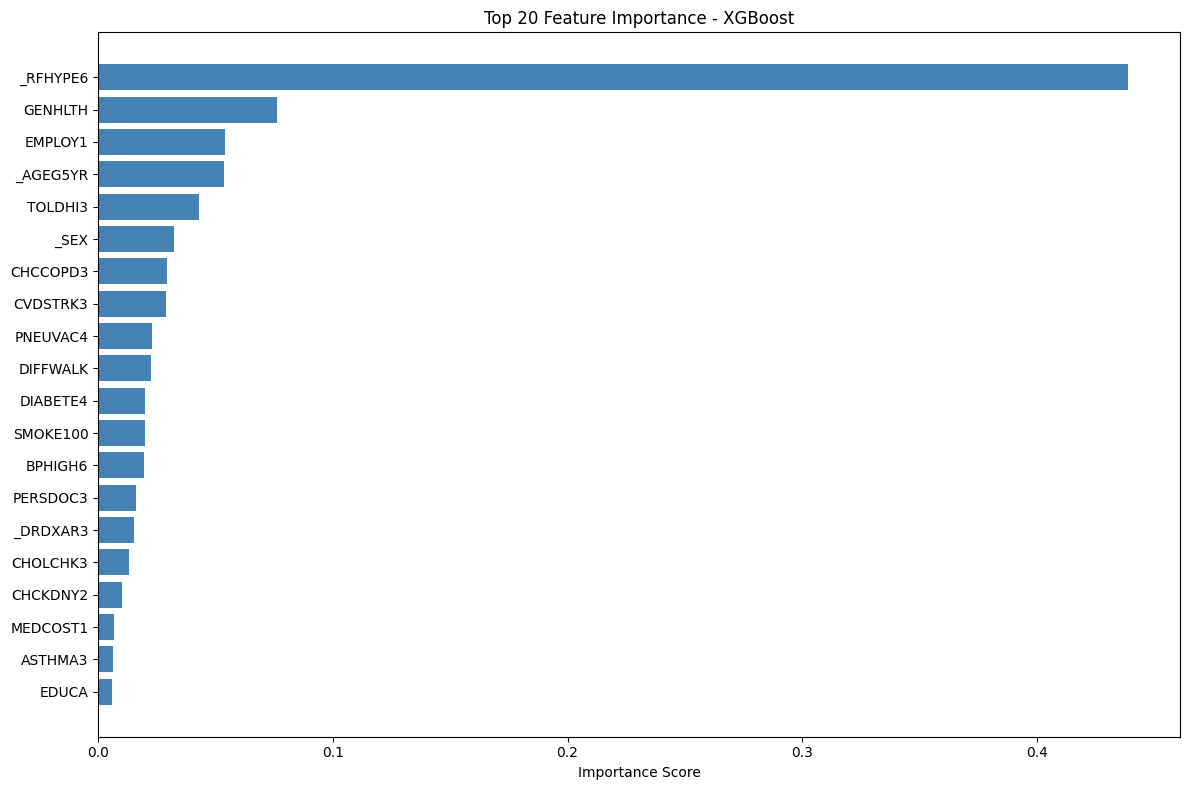

In [24]:
import matplotlib.pyplot as plt
# ── 1. Feature Importance dari model XGBoost yang sudah ditraining ──
importances = model.feature_importances_
feature_names = X_train.columns

feat_imp_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False).reset_index(drop=True)

print("Top 20 Feature Importance:")
print(feat_imp_df.head(50))

# %%
# ── 2. Plot Feature Importance ──
plt.figure(figsize=(12, 8))
top_n = 20
plt.barh(
    feat_imp_df['feature'][:top_n][::-1],
    feat_imp_df['importance'][:top_n][::-1],
    color='steelblue'
)
plt.xlabel('Importance Score')
plt.title(f'Top {top_n} Feature Importance - XGBoost')
plt.tight_layout()
plt.show()

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from imblearn.over_sampling import SMOTE, BorderlineSMOTE, ADASYN
from imblearn.combine import SMOTETomek, SMOTEENN
from imblearn.under_sampling import TomekLinks, NearMiss
from sklearn.metrics import (
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, recall_score, precision_score, accuracy_score,
    classification_report
)
from xgboost import XGBClassifier
import pandas as pd

# ── 1. Definisi kuartil & resamplers ─────────────────────────────────────────
kuartils = [1, 2, 3]

resamplers = {
    'scale_pos_weight' : None,
    'SMOTE'            : SMOTE(random_state=42),
    'BorderlineSMOTE'  : BorderlineSMOTE(random_state=42),
    'ADASYN'           : ADASYN(random_state=42),
    'SMOTETomek'       : SMOTETomek(random_state=42),
    'SMOTEENN'         : SMOTEENN(random_state=42),
    'TomekLinks'       : TomekLinks(n_jobs=-1),
    'NearMiss-1'       : NearMiss(version=1, n_jobs=-1),
    # 'NearMiss-2'       : NearMiss(version=2, n_jobs=-1),
    # 'NearMiss-3'       : NearMiss(version=3, n_jobs=-1),
}

N_total = len(feat_imp_df)  # ← dari XGBoost feature importance


# ── 2. Loop kuartil × resampler ───────────────────────────────────────────────
results_all   = {}
conf_matrices = {}

for Q in tqdm(kuartils, desc="Kuartil"):
    N_FEATURES        = int(np.ceil(N_total * Q / 4))
    selected_features = feat_imp_df['feature'].head(N_FEATURES).tolist()  # ← feat_imp_df

    X_train_q = X_train[selected_features]
    X_test_q  = X_test[selected_features]

    print(f"\n{'='*60}")
    print(f"  Kuartil Q={Q} ({Q*25}%) → {N_FEATURES} fitur")
    print(f"{'='*60}")

    for resampler_name, sampler in tqdm(resamplers.items(), desc=f"Q={Q}", leave=False):
        print(f"\n  [{resampler_name}]")

        # Resampling
        if sampler is None:
            X_res, y_res = X_train_q, y_train
            spw = (y_train == 0).sum() / (y_train == 1).sum()
        else:
            X_res, y_res = sampler.fit_resample(X_train_q, y_train)
            spw = 1.0

        print(f"  Shape train : {X_train_q.shape} → {X_res.shape}")

        # Retrain XGBoost
        xgb_fit = XGBClassifier(
            **{**model.get_params(), 'scale_pos_weight': spw}
        )
        xgb_fit.fit(X_res, y_res)

        y_pred = xgb_fit.predict(X_test_q)
        report = classification_report(y_test, y_pred, output_dict=True)

        print(classification_report(y_test, y_pred))

        key = f'Q{Q}_{resampler_name}'
        conf_matrices[key] = confusion_matrix(y_test, y_pred)
        results_all[key] = {
            'Kuartil'     : f'Q{Q} ({Q*25}%)',
            'N Fitur'     : N_FEATURES,
            'Resampler'   : resampler_name,
            'Accuracy'    : report['accuracy'],
            'F1 Macro'    : report['macro avg']['f1-score'],
            'F1 Weighted' : report['weighted avg']['f1-score'],
            'Precision'   : report['macro avg']['precision'],
            'Recall'      : report['macro avg']['recall'],
        }


# ── 3. Tabel perbandingan ─────────────────────────────────────────────────────
results_df = pd.DataFrame(results_all).T.round(4)
print("\n── Perbandingan Semua Kombinasi ──")
print(results_df.sort_values('F1 Macro', ascending=False).to_string())


# ── 4. Kombinasi terbaik ──────────────────────────────────────────────────────
best = results_df.sort_values('F1 Macro', ascending=False).iloc[0]
print(f"\n✅ Kombinasi terbaik:")
print(f"   Kuartil   : {best['Kuartil']}")
print(f"   N Fitur   : {best['N Fitur']}")
print(f"   Resampler : {best['Resampler']}")
print(f"   F1 Macro  : {best['F1 Macro']}")

Kuartil:   0%|          | 0/3 [00:00<?, ?it/s]


  Kuartil Q=1 (25%) → 9 fitur



  [scale_pos_weight]
  Shape train : (189095, 9) → (189095, 9)


              precision    recall  f1-score   support

           0       0.97      0.72      0.83     43074
           1       0.22      0.80      0.34      4200

    accuracy                           0.73     47274
   macro avg       0.60      0.76      0.59     47274
weighted avg       0.91      0.73      0.78     47274


  [SMOTE]
  Shape train : (189095, 9) → (344586, 9)


              precision    recall  f1-score   support

           0       0.97      0.77      0.85     43074
           1       0.23      0.73      0.35      4200

    accuracy                           0.76     47274
   macro avg       0.60      0.75      0.60     47274
weighted avg       0.90      0.76      0.81     47274


  [BorderlineSMOTE]
  Shape train : (189095, 9) → (344586, 9)


...

              precision    recall  f1-score   support

           0       0.93      0.98      0.95     43074
           1       0.46      0.21      0.29      4200

    accuracy                           0.91     47274
   macro avg       0.69      0.59      0.62     47274
weighted avg       0.89      0.91      0.89     47274


  [SMOTEENN]
  Shape train : (189095, 27) → (284844, 27)


              precision    recall  f1-score   support

           0       0.96      0.87      0.91     43074
           1       0.31      0.59      0.41      4200

    accuracy                           0.85     47274
   macro avg       0.63      0.73      0.66     47274
weighted avg       0.90      0.85      0.87     47274


  [TomekLinks]
  Shape train : (189095, 27) → (185702, 27)


              precision    recall  f1-score   support

           0       0.92      0.99      0.95     43074
           1       0.55      0.13      0.21      4200

    accuracy                           0.91     47274
   macro avg       0.74      0.56      0.58     47274
weighted avg       0.89      0.91      0.89     47274


  [NearMiss-1]
  Shape train : (189095, 27) → (33604, 27)


Kuartil: 100%|██████████| 3/3 [05:05<00:00, 101.87s/it]

              precision    recall  f1-score   support

           0       0.91      0.23      0.36     43074
           1       0.09      0.78      0.16      4200

    accuracy                           0.27     47274
   macro avg       0.50      0.50      0.26     47274
weighted avg       0.84      0.27      0.34     47274


── Perbandingan Semua Kombinasi ──
                      Kuartil N Fitur         Resampler  Accuracy  F1 Macro F1 Weighted Precision    Recall
Q2_SMOTEENN          Q2 (50%)      18          SMOTEENN  0.865909  0.664644     0.87828  0.642071  0.706811
Q3_SMOTEENN          Q3 (75%)      27          SMOTEENN  0.847908  0.660152    0.867871  0.633858  0.730991
Q2_SMOTE             Q2 (50%)      18             SMOTE  0.862123  0.648616     0.87385  0.629524  0.682923
Q2_SMOTETomek        Q2 (50%)      18        SMOTETomek  0.861213  0.648159      0.8733  0.628827  0.683498
Q2_ADASYN            Q2 (50%)      18            ADASYN  0.859204  0.644104    0.871623    0.6252

In [27]:
class_labels = [0,1]
class_labels

[0, 1]

In [28]:
# ── 2. Helper plot confusion matrix ─────────────────────────────────────────
def plot_confusion_matrix(y_true, y_pred, model_name, percentile, class_labels):
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)  # normalized per baris

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Confusion Matrix — {model_name} | P={percentile}%', fontsize=13, fontweight='bold')

    # Raw counts
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=class_labels, yticklabels=class_labels,
        ax=axes[0], linewidths=0.5
    )
    axes[0].set_title('Raw Count')
    axes[0].set_xlabel('Predicted Label')
    axes[0].set_ylabel('True Label')

    # Normalized
    sns.heatmap(
        cm_norm, annot=True, fmt='.2f', cmap='Blues',
        xticklabels=class_labels, yticklabels=class_labels,
        ax=axes[1], linewidths=0.5, vmin=0, vmax=1
    )
    axes[1].set_title('Normalized (per True Class)')
    axes[1].set_xlabel('Predicted Label')
    axes[1].set_ylabel('True Label')

    plt.tight_layout()
    plt.show()

Kuartil:   0%|          | 0/2 [00:00<?, ?it/s]


  Kuartil Q=2 (50%) → 18 fitur
  Shape train : (189095, 18) → (248213, 18)



  [XGBoost]
  Training Time : 1.5916s
  ROC-AUC       : 0.8441
              precision    recall  f1-score   support

           0       0.95      0.92      0.93     43074
           1       0.36      0.46      0.40      4200

    accuracy                           0.88     47274
   macro avg       0.65      0.69      0.67     47274
weighted avg       0.89      0.88      0.89     47274



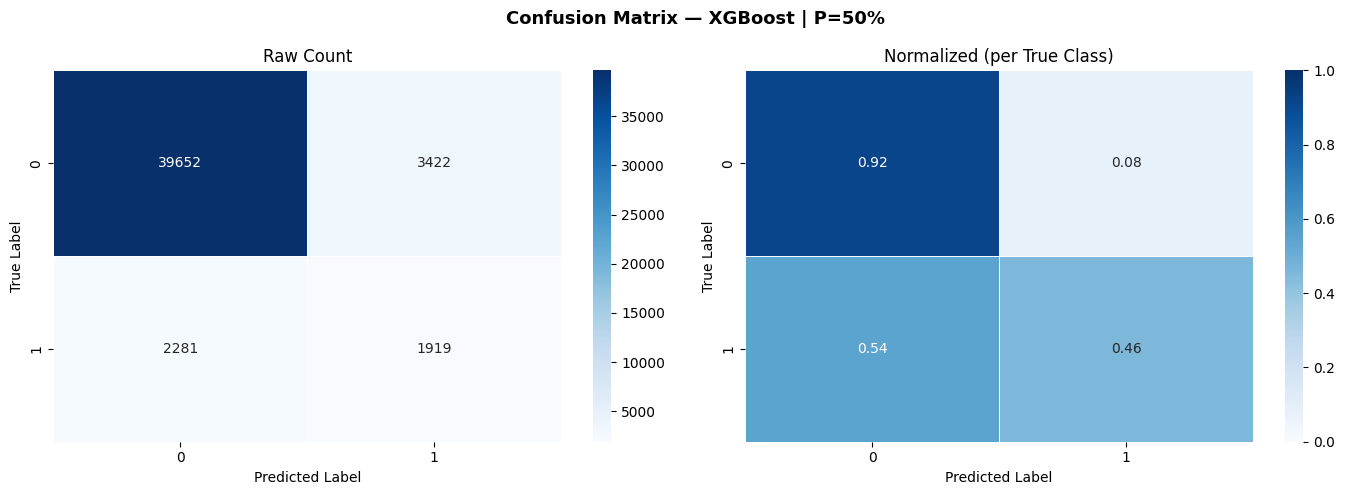


  [LightGBM]
  Training Time : 3.0392s


/opt/homebrew/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  ROC-AUC       : 0.8440
              precision    recall  f1-score   support

           0       0.94      0.92      0.93     43074
           1       0.36      0.45      0.40      4200

    accuracy                           0.88     47274
   macro avg       0.65      0.69      0.67     47274
weighted avg       0.89      0.88      0.89     47274



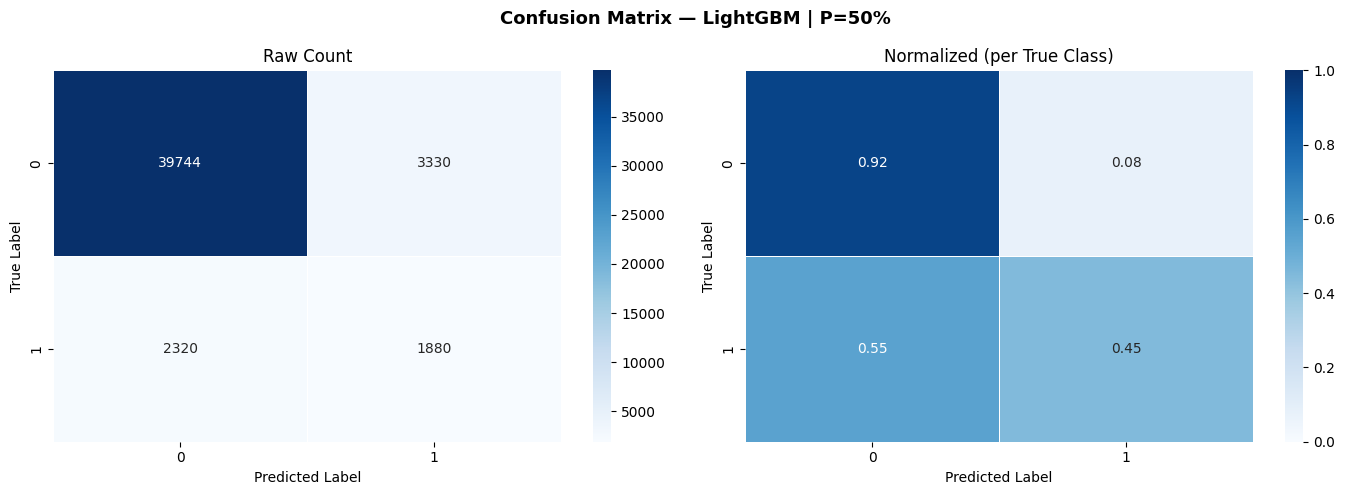


  [CatBoost]
  Training Time : 5.8954s
  ROC-AUC       : 0.8428
              precision    recall  f1-score   support

           0       0.94      0.93      0.94     43074
           1       0.38      0.41      0.40      4200

    accuracy                           0.89     47274
   macro avg       0.66      0.67      0.67     47274
weighted avg       0.89      0.89      0.89     47274



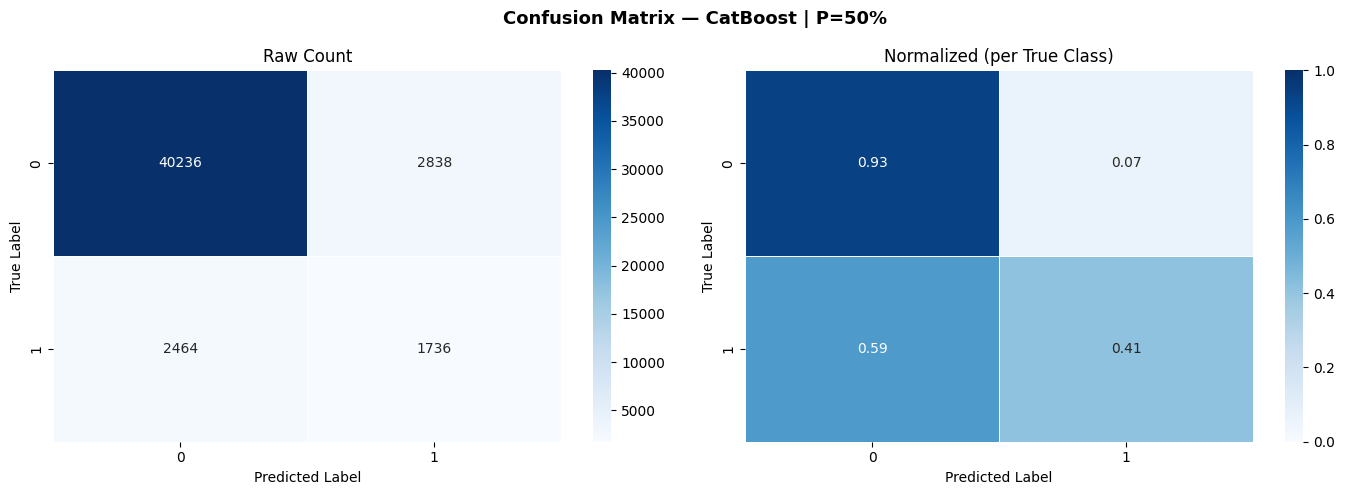


  [RandomForest]
  Training Time : 4.0214s
  ROC-AUC       : 0.8321
              precision    recall  f1-score   support

           0       0.96      0.79      0.87     43074
           1       0.25      0.70      0.37      4200

    accuracy                           0.78     47274
   macro avg       0.61      0.75      0.62     47274
weighted avg       0.90      0.78      0.83     47274



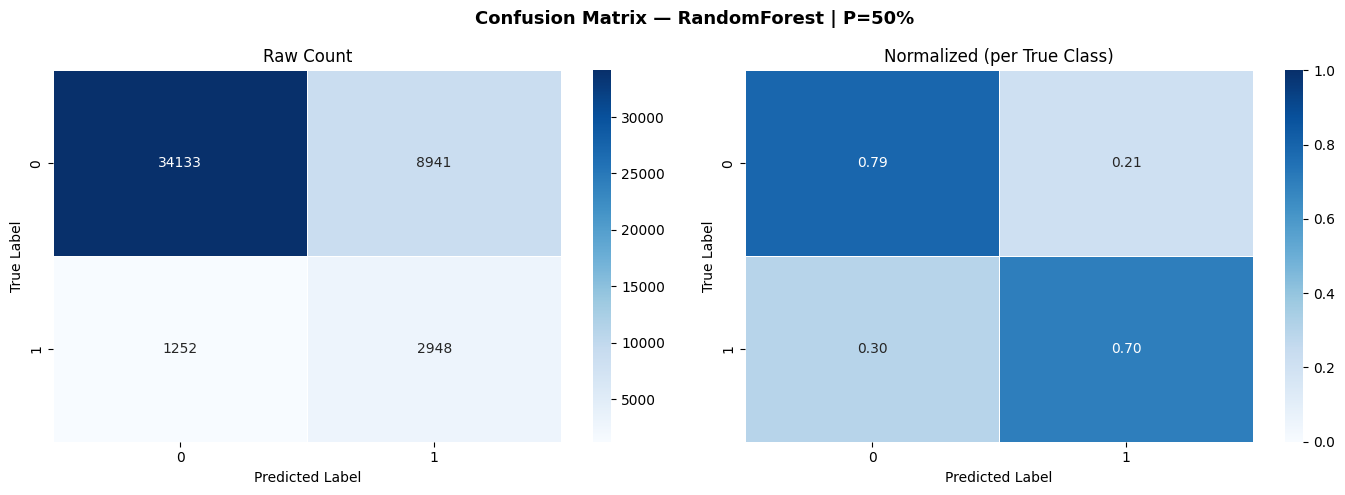


  [ExtraTrees]
  Training Time : 2.9219s
  ROC-AUC       : 0.8256
              precision    recall  f1-score   support

           0       0.97      0.75      0.84     43074
           1       0.22      0.75      0.35      4200

    accuracy                           0.75     47274
   macro avg       0.60      0.75      0.59     47274
weighted avg       0.90      0.75      0.80     47274



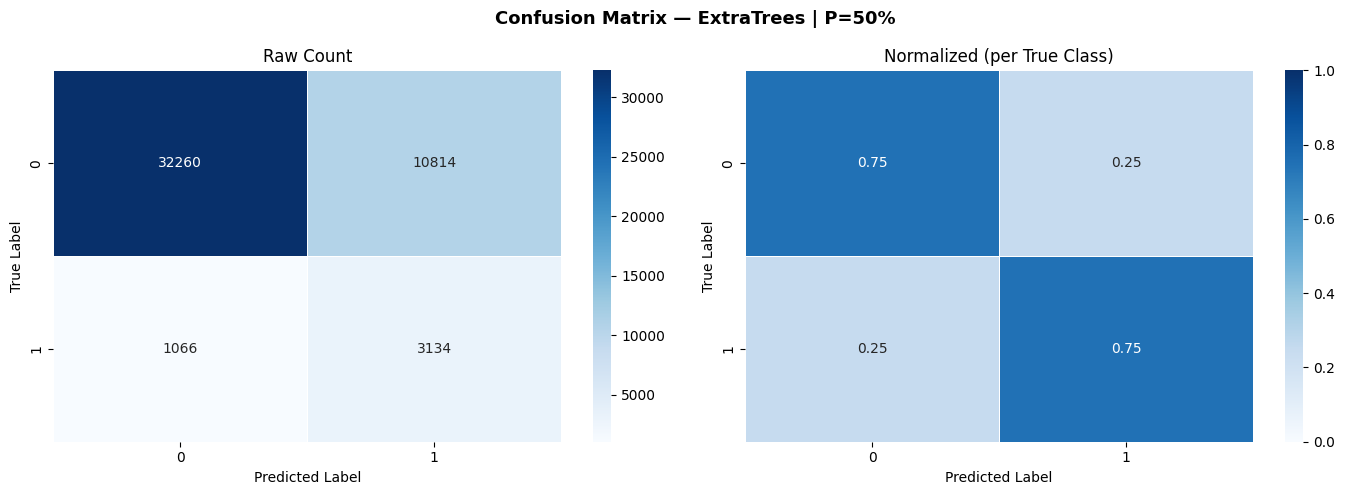


  [GradientBoosting]
  Training Time : 58.3649s
  ROC-AUC       : 0.8440
              precision    recall  f1-score   support

           0       0.95      0.88      0.91     43074
           1       0.31      0.57      0.40      4200

    accuracy                           0.85     47274
   macro avg       0.63      0.72      0.66     47274
weighted avg       0.90      0.85      0.87     47274



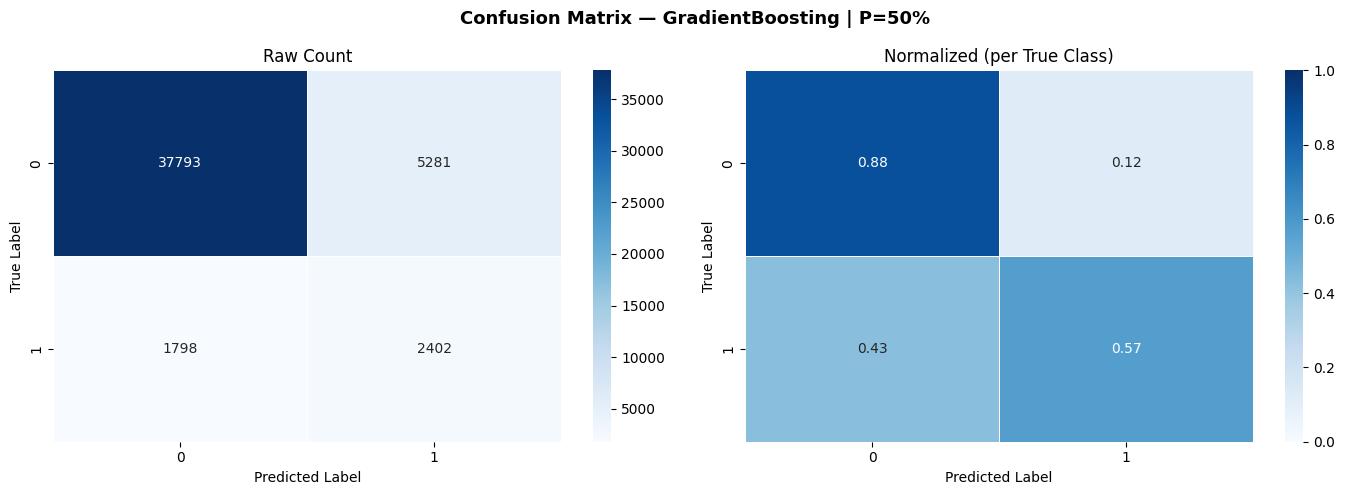


  [LogisticRegression]
  Training Time : 0.4214s
  ROC-AUC       : 0.8380
              precision    recall  f1-score   support

           0       0.97      0.75      0.85     43074
           1       0.23      0.77      0.36      4200

    accuracy                           0.75     47274
   macro avg       0.60      0.76      0.60     47274
weighted avg       0.91      0.75      0.80     47274



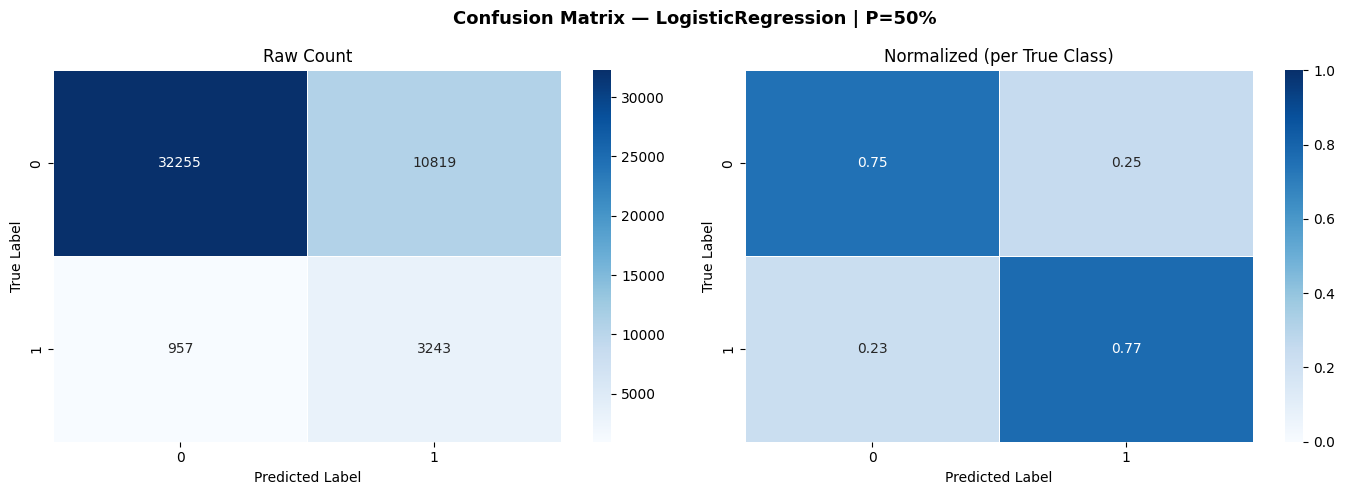


  [KNN]
  Training Time : 0.0203s
  ROC-AUC       : 0.7201
              precision    recall  f1-score   support

           0       0.95      0.83      0.88     43074
           1       0.23      0.54      0.32      4200

    accuracy                           0.80     47274
   macro avg       0.59      0.68      0.60     47274
weighted avg       0.88      0.80      0.83     47274



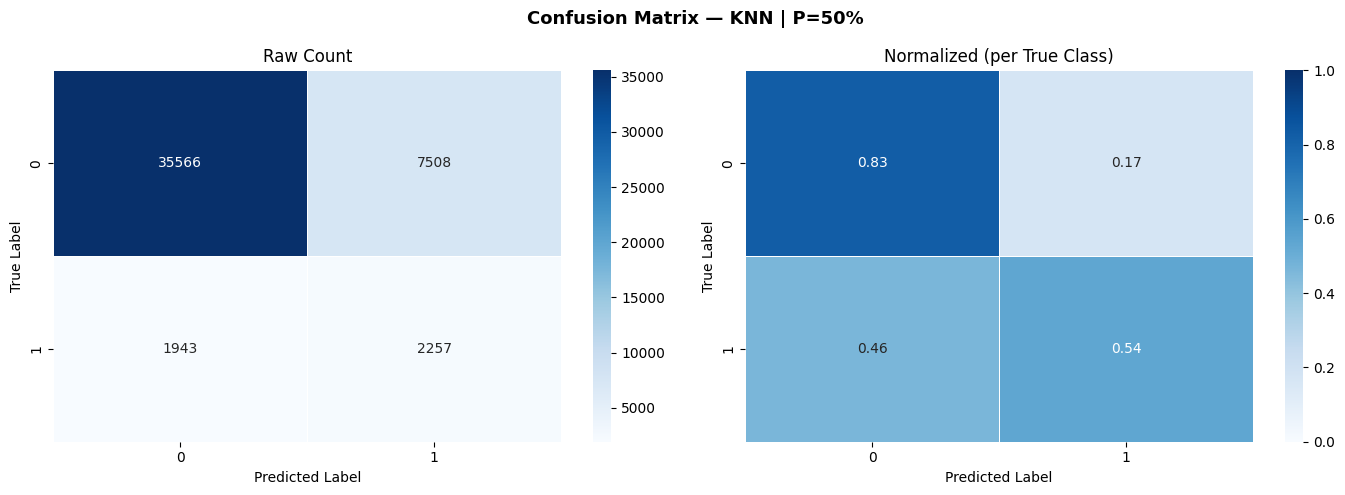

Kuartil:  50%|█████     | 1/2 [02:18<02:18, 138.84s/it]


  Kuartil Q=3 (75%) → 27 fitur
  Shape train : (189095, 27) → (284844, 27)



  [XGBoost]
  Training Time : 2.0150s
  ROC-AUC       : 0.8464
              precision    recall  f1-score   support

           0       0.95      0.89      0.92     43074
           1       0.33      0.56      0.41      4200

    accuracy                           0.86     47274
   macro avg       0.64      0.72      0.67     47274
weighted avg       0.90      0.86      0.87     47274



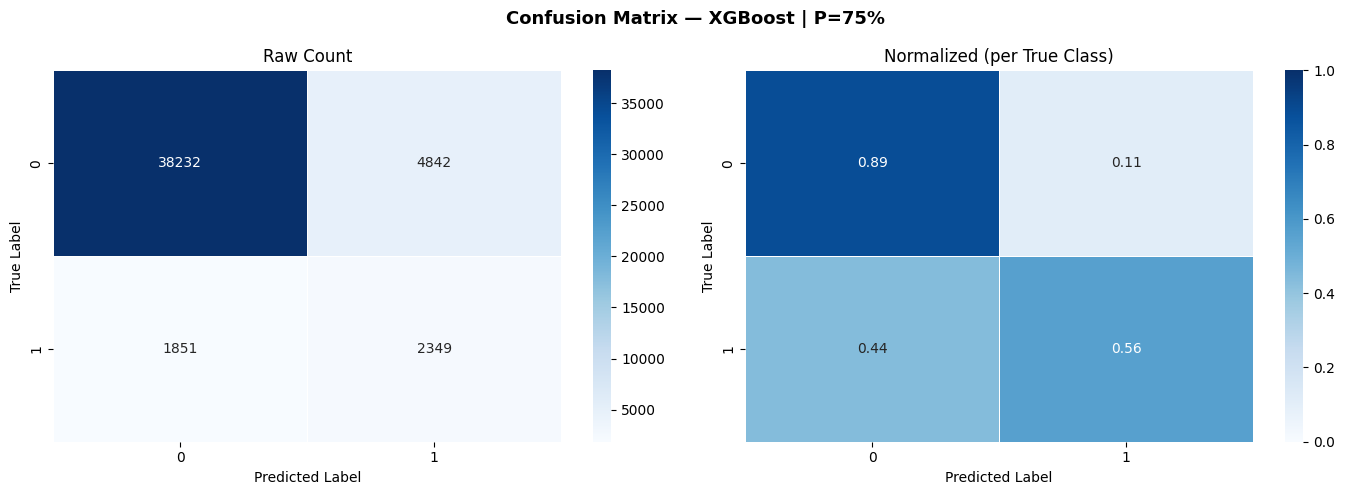


  [LightGBM]
  Training Time : 3.1888s


/opt/homebrew/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  ROC-AUC       : 0.8462
              precision    recall  f1-score   support

           0       0.95      0.89      0.92     43074
           1       0.33      0.55      0.41      4200

    accuracy                           0.86     47274
   macro avg       0.64      0.72      0.67     47274
weighted avg       0.90      0.86      0.88     47274



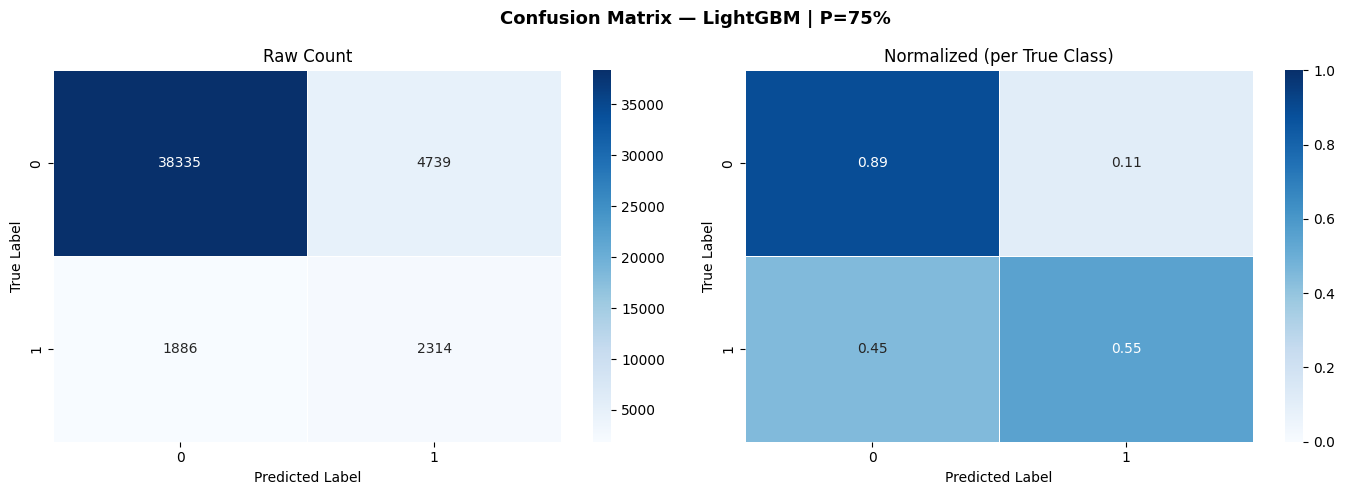


  [CatBoost]
  Training Time : 7.0028s
  ROC-AUC       : 0.8465
              precision    recall  f1-score   support

           0       0.95      0.89      0.92     43074
           1       0.33      0.54      0.41      4200

    accuracy                           0.86     47274
   macro avg       0.64      0.72      0.67     47274
weighted avg       0.90      0.86      0.88     47274



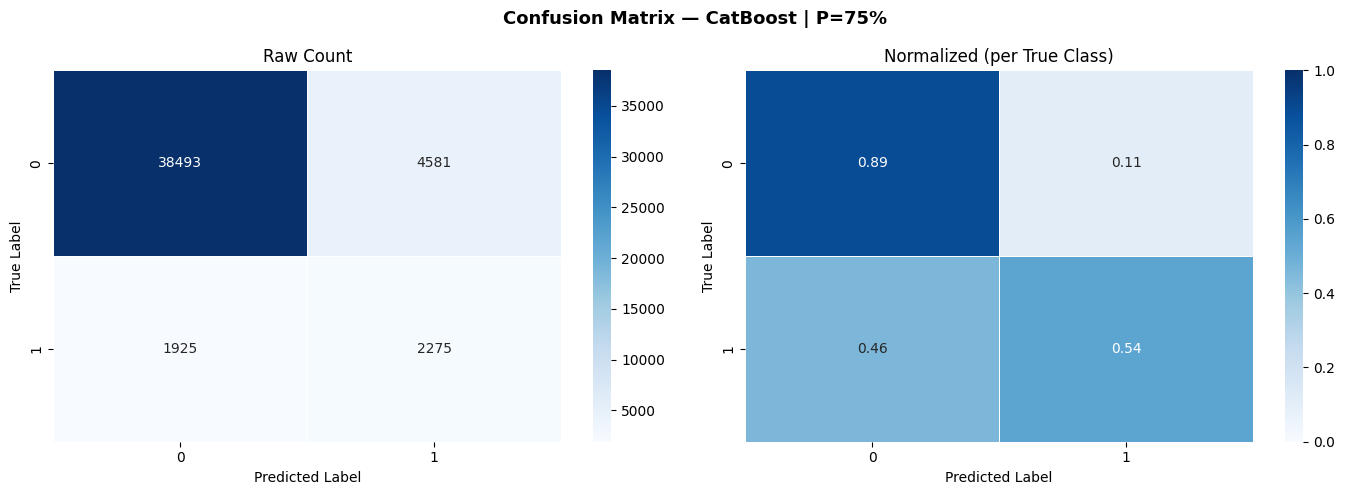


  [RandomForest]
  Training Time : 7.5492s
  ROC-AUC       : 0.8283
              precision    recall  f1-score   support

           0       0.97      0.70      0.81     43074
           1       0.21      0.81      0.33      4200

    accuracy                           0.71     47274
   macro avg       0.59      0.76      0.57     47274
weighted avg       0.91      0.71      0.77     47274



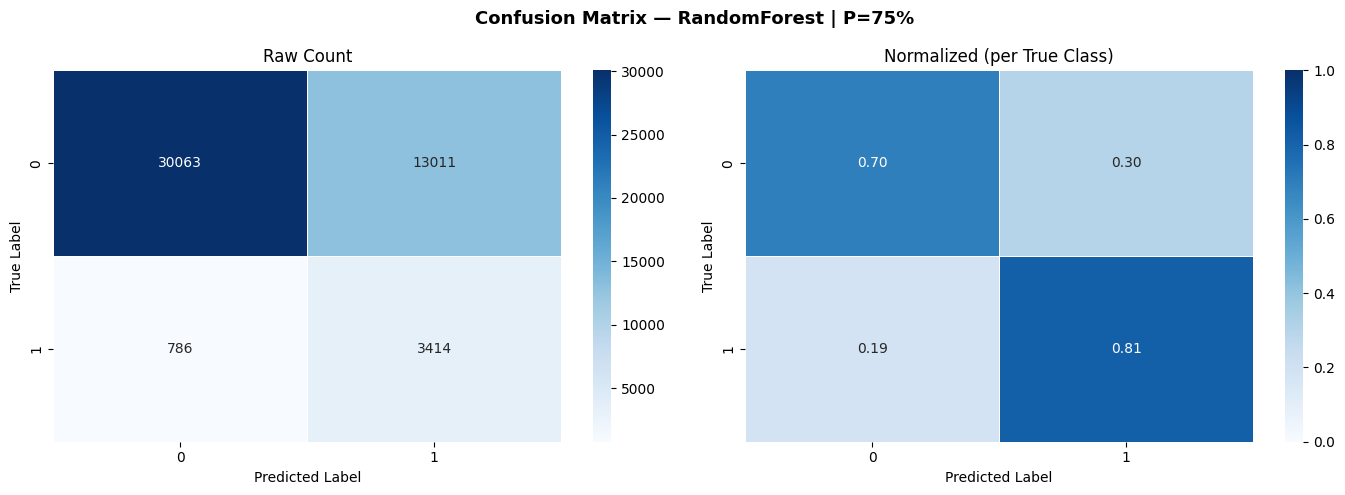


  [ExtraTrees]
  Training Time : 3.5633s
  ROC-AUC       : 0.8206
              precision    recall  f1-score   support

           0       0.98      0.62      0.76     43074
           1       0.18      0.86      0.30      4200

    accuracy                           0.64     47274
   macro avg       0.58      0.74      0.53     47274
weighted avg       0.91      0.64      0.72     47274



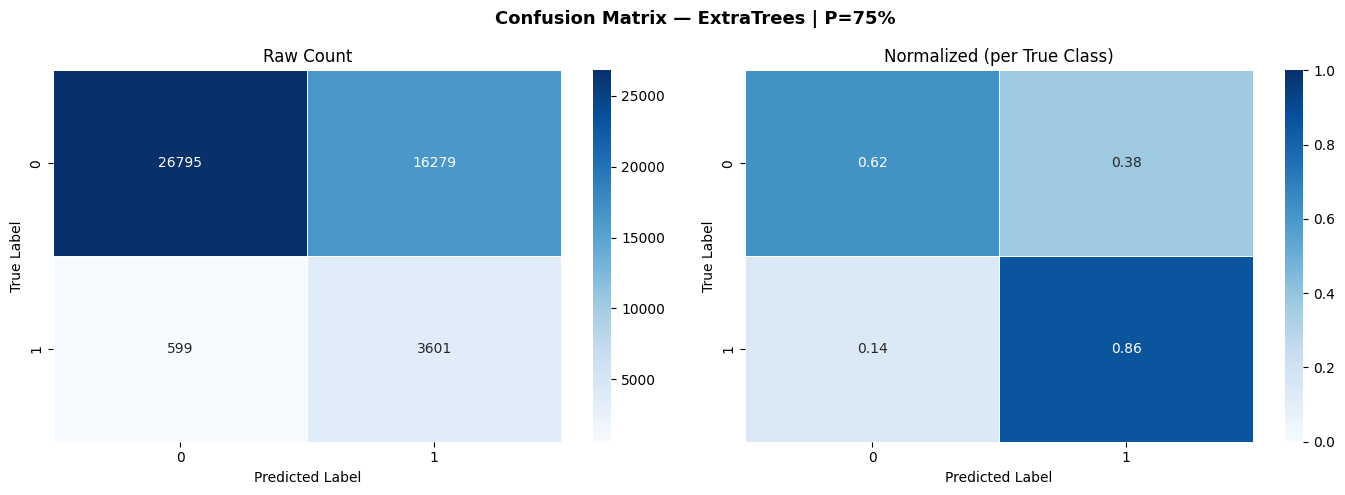


  [GradientBoosting]
  Training Time : 138.8720s
  ROC-AUC       : 0.8428
              precision    recall  f1-score   support

           0       0.96      0.86      0.91     43074
           1       0.30      0.61      0.40      4200

    accuracy                           0.84     47274
   macro avg       0.63      0.74      0.65     47274
weighted avg       0.90      0.84      0.86     47274



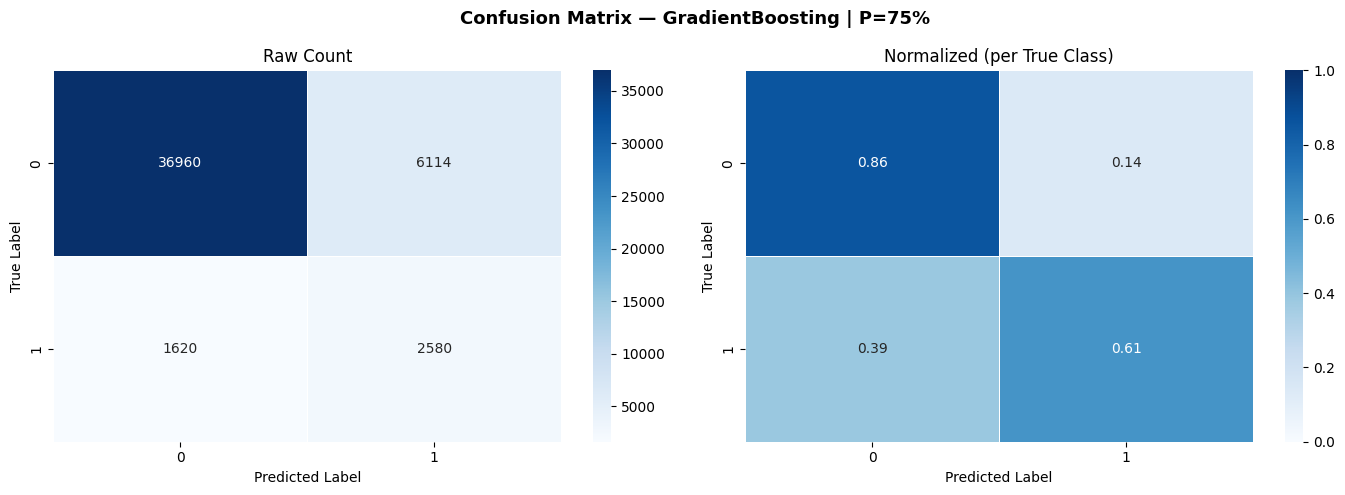


  [LogisticRegression]
  Training Time : 0.8681s
  ROC-AUC       : 0.8404
              precision    recall  f1-score   support

           0       0.98      0.64      0.78     43074
           1       0.19      0.88      0.31      4200

    accuracy                           0.66     47274
   macro avg       0.59      0.76      0.55     47274
weighted avg       0.91      0.66      0.73     47274



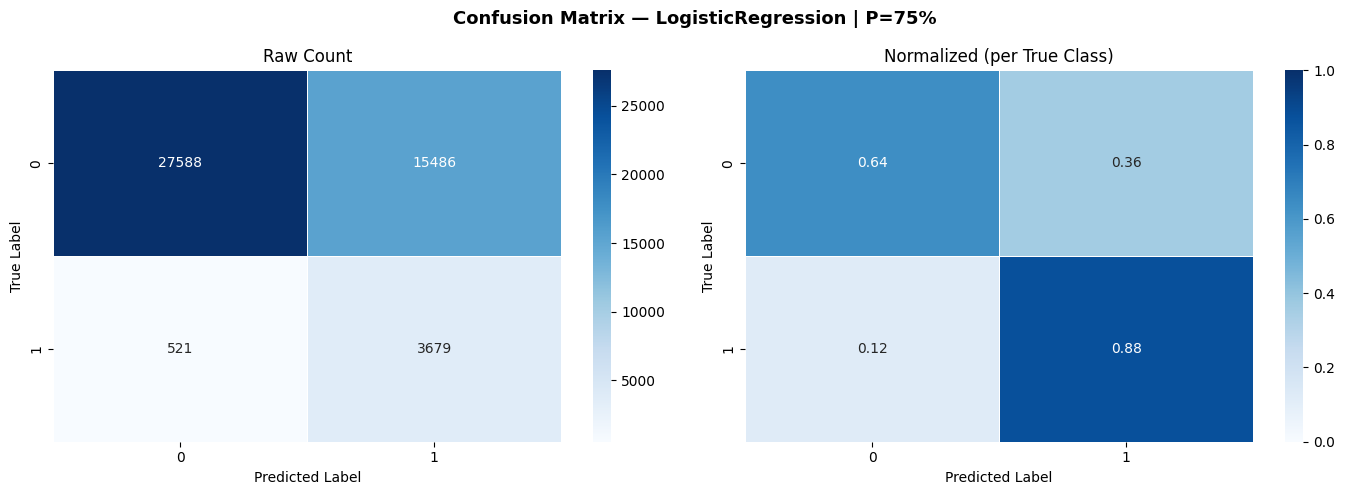


  [KNN]
  Training Time : 0.0227s
  ROC-AUC       : 0.7689
              precision    recall  f1-score   support

           0       0.96      0.76      0.85     43074
           1       0.22      0.68      0.33      4200

    accuracy                           0.75     47274
   macro avg       0.59      0.72      0.59     47274
weighted avg       0.89      0.75      0.80     47274



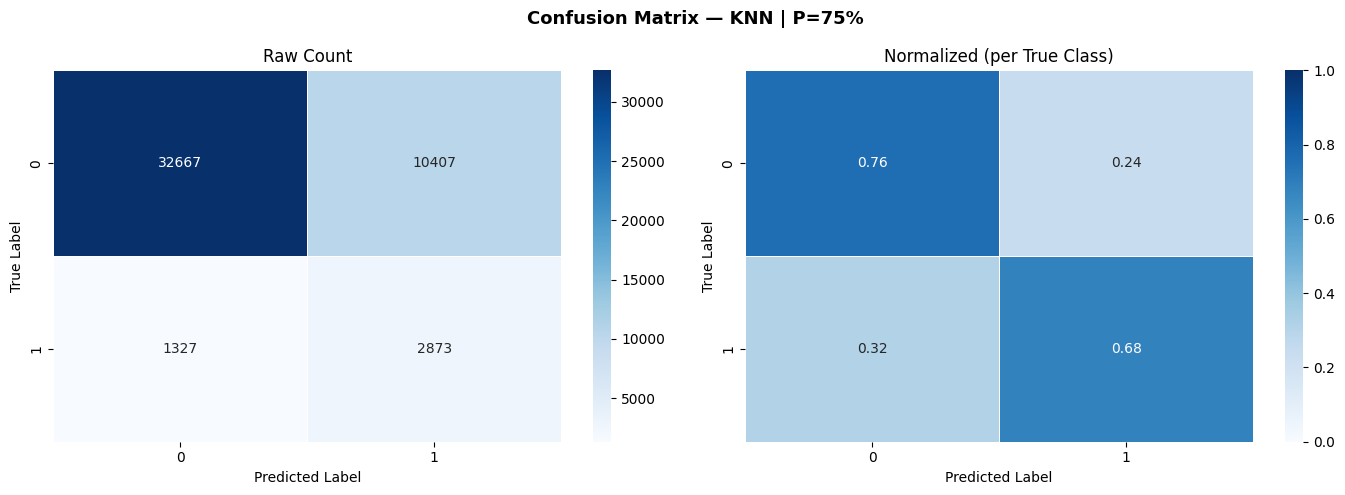

Kuartil: 100%|██████████| 2/2 [06:11<00:00, 185.78s/it]


── Perbandingan Semua Kombinasi (SMOTEENN) ──
                        Kuartil N Fitur               Model  Accuracy  F1 Macro F1 Weighted Precision    Recall ROC-AUC Training Time
Q2_XGBoost             Q2 (50%)      18             XGBoost  0.879363  0.667588    0.885767   0.65245   0.68873  0.8441        1.5916
Q2_CatBoost            Q2 (50%)      18            CatBoost  0.887845  0.666951    0.889991  0.660916  0.673723  0.8428        5.8954
Q3_CatBoost            Q3 (75%)      27            CatBoost  0.862377  0.666809    0.876719  0.642099  0.717657  0.8465        7.0028
Q2_LightGBM            Q2 (50%)      18            LightGBM  0.880484  0.666606    0.886189  0.652845  0.685155   0.844        3.0392
Q3_XGBoost             Q3 (75%)      27             XGBoost  0.858421  0.665972    0.874463   0.64024  0.723437  0.8464         2.015
Q3_LightGBM            Q3 (75%)      27            LightGBM   0.85986  0.665866    0.875225  0.640598  0.720466  0.8462        3.1888
Q2_GradientBoos

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

from imblearn.combine import SMOTEENN
from sklearn.metrics import (
    f1_score, recall_score, precision_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.base import clone

from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier

from sklearn.preprocessing import MinMaxScaler
import time


# ── 1. KONFIGURASI ───────────────────────────────────────────────────────────
kuartils = [2, 3]

N_total = len(feat_imp_df)

# ── 2. MODEL ─────────────────────────────────────────────────────────────────
models = {
    'XGBoost': XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='logloss', random_state=42, n_jobs=-1
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, n_jobs=-1, verbose=-1
    ),
    'CatBoost': CatBoostClassifier(
        iterations=300, depth=6, learning_rate=0.05,
        random_state=42, verbose=0
    ),
    'RandomForest': RandomForestClassifier(
        n_estimators=300, max_depth=6,
        random_state=42, n_jobs=-1
    ),
    'ExtraTrees': ExtraTreesClassifier(
        n_estimators=300, max_depth=6,
        random_state=42, n_jobs=-1
    ),
    'GradientBoosting': GradientBoostingClassifier(
        n_estimators=300, learning_rate=0.05,
        random_state=42
    ),
    'LogisticRegression': LogisticRegression(
        max_iter=1000, random_state=42
    ),
    'KNN': KNeighborsClassifier(
        n_neighbors=5
    ),
}

# ── Helper: hitung ROC-AUC aman (handle model tanpa predict_proba) ───────────
def compute_roc_auc(clf, X, y_true):
    """
    Mengembalikan ROC-AUC score.
    - Binary   : pakai predict_proba[:, 1] atau decision_function
    - Multiclass: pakai predict_proba + ovr + weighted
    """
    n_classes = len(np.unique(y_true))
    try:
        if hasattr(clf, "predict_proba"):
            y_prob = clf.predict_proba(X)
            if n_classes == 2:
                return roc_auc_score(y_true, y_prob[:, 1])
            else:
                return roc_auc_score(y_true, y_prob, multi_class='ovr', average='weighted')
        elif hasattr(clf, "decision_function"):
            y_score = clf.decision_function(X)
            if n_classes == 2:
                return roc_auc_score(y_true, y_score)
            else:
                return roc_auc_score(y_true, y_score, multi_class='ovr', average='weighted')
        else:
            return np.nan  # model tidak support probabilitas
    except Exception as e:
        print(f"    ⚠️  ROC-AUC gagal dihitung: {e}")
        return np.nan


# ── 3. Loop kuartil × model ──────────────────────────────────────────────────
results_all   = {}
conf_matrices = {}

for Q in tqdm(kuartils, desc="Kuartil"):
    N_FEATURES        = int(np.ceil(N_total * Q / 4))
    selected_features = feat_imp_df['feature'].head(N_FEATURES).tolist()

    X_train_q = X_train[selected_features]
    X_test_q  = X_test[selected_features]

    X_res, y_res = SMOTEENN(random_state=42).fit_resample(X_train_q, y_train)

    scaler = MinMaxScaler()
    X_res_scaled  = scaler.fit_transform(X_res)
    X_test_scaled = scaler.transform(X_test_q)

    print(f"\n{'='*60}")
    print(f"  Kuartil Q={Q} ({Q*25}%) → {N_FEATURES} fitur")
    print(f"  Shape train : {X_train_q.shape} → {X_res.shape}")
    print(f"{'='*60}")

    for model_name, clf in tqdm(models.items(), desc=f"Q={Q}", leave=False):
        print(f"\n  [{model_name}]")

        clf_fit = clone(clf)

        start = time.time()
        clf_fit.fit(X_res_scaled, y_res)
        train_time = time.time() - start
        print(f"  Training Time : {train_time:.4f}s")

        y_pred = clf_fit.predict(X_test_scaled)
        report = classification_report(y_test, y_pred, output_dict=True)

        # ✅ Hitung ROC-AUC
        auc_score = compute_roc_auc(clf_fit, X_test_scaled, y_test)
        print(f"  ROC-AUC       : {auc_score:.4f}" if not np.isnan(auc_score) else "  ROC-AUC       : N/A")

        print(classification_report(y_test, y_pred, target_names=[str(x) for x in class_labels]))

        plot_confusion_matrix(y_test, y_pred, model_name, Q*25, class_labels)

        key = f'Q{Q}_{model_name}'
        conf_matrices[key] = confusion_matrix(y_test, y_pred)
        results_all[key] = {
            'Kuartil'      : f'Q{Q} ({Q*25}%)',
            'N Fitur'      : N_FEATURES,
            'Model'        : model_name,
            'Accuracy'     : report['accuracy'],
            'F1 Macro'     : report['macro avg']['f1-score'],
            'F1 Weighted'  : report['weighted avg']['f1-score'],
            'Precision'    : report['macro avg']['precision'],
            'Recall'       : report['macro avg']['recall'],
            'ROC-AUC'      : round(auc_score, 4) if not np.isnan(auc_score) else np.nan,  # ✅ tambahan
            'Training Time': round(train_time, 4),
        }


# ── 4. Tabel perbandingan ─────────────────────────────────────────────────────
results_df = pd.DataFrame(results_all).T.round(4)
print("\n── Perbandingan Semua Kombinasi (SMOTEENN) ──")
print(results_df.sort_values('F1 Macro', ascending=False).to_string())


# ── 5. Kombinasi terbaik ──────────────────────────────────────────────────────
best = results_df.sort_values('F1 Macro', ascending=False).iloc[0]
print(f"\n✅ Kombinasi terbaik:")
print(f"   Kuartil   : {best['Kuartil']}")
print(f"   N Fitur   : {best['N Fitur']}")
print(f"   Model     : {best['Model']}")
print(f"   F1 Macro  : {best['F1 Macro']}")
print(f"   ROC-AUC   : {best['ROC-AUC']}")   # ✅ tambahan